In [28]:
from google import genai
from dotenv import load_dotenv
import os


from tqdm import tqdm
tqdm.pandas()

load_dotenv()
api_key = os.getenv("GEMINI_API_KEY")
client = genai.Client(api_key=api_key)


df_merged = pd.read_json("merged_quotes.jsonl", lines=True)
df_sample = df_merged.sample(n=100, random_state=42).copy()



def predict_real_or_fake(quote):
    prompt = f"""
You are an expert on famous quotes.
Determine whether the following quote is REAL (from a real author) or FAKE (made-up).

Quote:
\"{quote}\"

Respond only with one word: REAL or FAKE.
"""
    try:
        response = client.models.generate_content(
            model="gemini-2.0-flash",
            contents=prompt
        )
        return response.text.strip().upper()
    except Exception as e:
        return f"ERROR: {e}"

# Step 5: Run prediction with progress bar
df_sample["model_prediction"] = df_sample["quote"].progress_apply(predict_real_or_fake)



100%|███████████████████████████████████████████| 100/100 [01:01<00:00,  1.61it/s]


In [29]:
df_sample.to_json("sample_with_predictions_passing_only_quotes.jsonl", orient="records", lines=True, force_ascii=False)

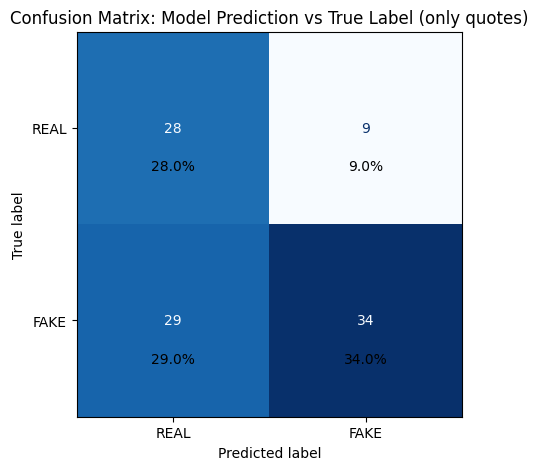

In [37]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np

# 1. Map predictions
def map_prediction(pred):
    if pred == "REAL":
        return False
    elif pred == "FAKE":
        return True
    else:
        return None

df_sample["predicted_is_fake"] = df_sample["model_prediction"].apply(map_prediction)

df_valid = df_sample.dropna(subset=["predicted_is_fake"])

y_true = df_valid["is_fake"]
y_pred = df_valid["predicted_is_fake"]

cm = confusion_matrix(y_true, y_pred, labels=[False, True])
cm_sum = cm.sum()
cm_percent = cm / cm_sum * 100

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["REAL", "FAKE"])
disp.plot(cmap="Blues", ax=ax, values_format='d', colorbar=False)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        count = cm[i, j]
        percent = cm_percent[i, j]
        ax.text(j, i + 0.2, f"{percent:.1f}%", ha="center", va="center", color="black", fontsize=10)

plt.title("Confusion Matrix: Model Prediction vs True Label (only quotes)")
plt.savefig("./confusion_matrix_only_quote.png", dpi=300)
plt.show()

100%|█████████████████████████████████████████| 100/100 [01:05<00:00,  1.52it/s]

Accuracy: 82.00% (100 valid samples)


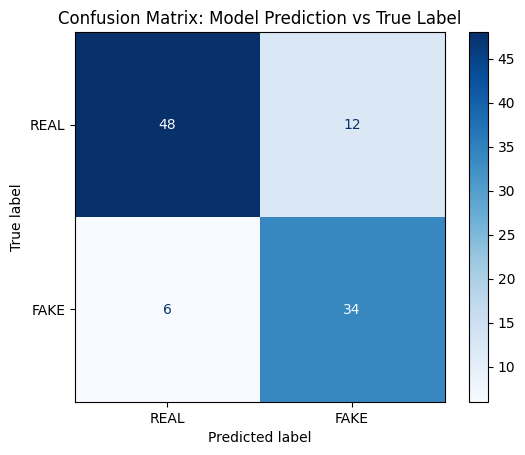

In [18]:
df_merged = pd.read_json("merged_quotes.jsonl", lines=True)

df_merged = df_merged[df_merged["author"].notna()]

df_sample = df_merged.sample(n=100, random_state=42).copy()

tqdm.pandas()

def predict_real_or_fake(row):
    quote = row["quote"]
    author = row["author"]

    prompt = f"""
You are an expert on famous quotes.
Determine whether the following quote is REAL (genuinely from the stated author) or FAKE (made-up).

Quote:
\"{quote}\"

Claimed Author:
\"{author}\"

Respond only with one word: REAL or FAKE.
"""
    try:
        response = client.models.generate_content(
            model="gemini-2.0-flash",
            contents=prompt
        )
        return response.text.strip().upper()
    except Exception as e:
        return f"ERROR: {e}"

df_sample["model_prediction"] = df_sample.progress_apply(predict_real_or_fake, axis=1)

def map_prediction(pred):
    if pred == "REAL":
        return False
    elif pred == "FAKE":
        return True
    else:
        return None

df_sample["predicted_is_fake"] = df_sample["model_prediction"].apply(map_prediction)

df_valid = df_sample.dropna(subset=["predicted_is_fake"])

accuracy = (df_valid["is_fake"] == df_valid["predicted_is_fake"]).mean()
print(f"Accuracy: {accuracy:.2%} ({len(df_valid)} valid samples)")

y_true = df_valid["is_fake"]
y_pred = df_valid["predicted_is_fake"]

cm = confusion_matrix(y_true, y_pred, labels=[False, True])

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["REAL", "FAKE"])
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix: Model Prediction vs True Label")
plt.show()

In [33]:
df_merged = pd.read_json("merged_quotes.jsonl", lines=True)

df_with_author = df_merged[df_merged["author"].notna()].copy()

tqdm.pandas()

def predict_real_or_fake(row):
    quote = row["quote"]
    author = row["author"]

    prompt = f"""
You are an expert on famous quotes.
Determine whether the following quote is REAL (genuinely from the stated author) or FAKE (made-up).

Quote:
\"{quote}\"

Claimed Author:
\"{author}\"

Respond only with one word: REAL or FAKE.
"""
    try:
        response = client.models.generate_content(
            model="gemini-2.0-flash",
            contents=prompt
        )
        return response.text.strip().upper()
    except Exception as e:
        return f"ERROR: {e}"

df_with_author["model_prediction"] = df_with_author.progress_apply(predict_real_or_fake, axis=1)



  0%|                                            | 9/4113 [00:05<40:16,  1.70it/s]


KeyboardInterrupt: 

In [21]:
df_with_author.to_csv("temp_save.csv")

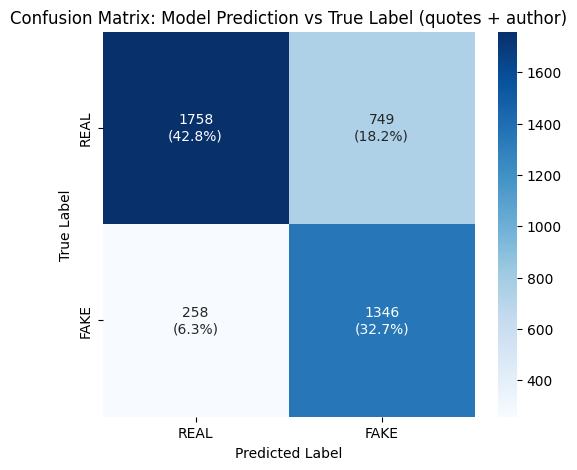

In [38]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix
df_with_author = pd.read_csv("./temp_save.csv")

df_valid = df_with_author.dropna(subset=["predicted_is_fake"])
df_valid = df_valid[df_valid["is_fake"].isin([True, False])]
df_valid = df_valid[df_valid["predicted_is_fake"].isin([True, False])]

y_true = df_valid["is_fake"].astype(bool)
y_pred = df_valid["predicted_is_fake"].astype(bool)

cm = confusion_matrix(y_true, y_pred, labels=[False, True])
cm_sum = cm.sum()
cm_percent = cm / cm_sum * 100

annot = np.empty_like(cm).astype(str)
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        count = cm[i, j]
        percent = cm_percent[i, j]
        annot[i, j] = f"{count}\n({percent:.1f}%)"

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=annot, fmt="", cmap="Blues", xticklabels=["REAL", "FAKE"], yticklabels=["REAL", "FAKE"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix: Model Prediction vs True Label (quotes + author)")
plt.savefig("./confusion_matrix_quote_and_author.png", dpi=300)
plt.show()
